In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('titanic')

print("Path to competition files:", path)

c:\Users\axeld\VSCode\Kaggle\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to competition files: C:\Users\axeld\.cache\kagglehub\competitions\titanic


In [2]:
from pathlib import Path
import pandas as pd

data_dir = Path(path)

print([file.name for file in data_dir.iterdir()])

train_data = pd.read_csv(data_dir / "train.csv")

train_data

['gender_submission.csv', 'test.csv', 'train.csv']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
train_data.max(numeric_only=True)

PassengerId    891.0000
Survived         1.0000
Pclass           3.0000
Age             80.0000
SibSp            8.0000
Parch            6.0000
Fare           512.3292
dtype: float64

In [ ]:
from pandas import DataFrame
import numpy as np

feature_columns = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Cabin"]
categorical_columns = ["Embarked", "Cabin_letter", "SexClass", "Title"]
label_col = "Survived"

def process_data(df: DataFrame):

    titles = df["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()
    titles = titles.replace({
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs",
    })

    title_categories = ["Mr", "Mrs", "Miss", "Master", "Rare", "Unknown"]
    titles = titles.fillna("Unknown")
    titles = titles.where(titles.isin(title_categories), "Rare")

    df = df[feature_columns]
    df["Title"] = pd.Categorical(titles, categories=title_categories)
    df["Family_size"] = df["SibSp"] + df["Parch"] + 1

    cabin_categories = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']
    df["Cabin_letter"] = pd.Categorical(df["Cabin"].str[0], categories=cabin_categories)

    df["Missing_age"] = df["Age"].isna().astype(int)
    df["Fare"] = np.log1p(df["Fare"])
    df["SexClass"] = (
        df["Sex"] + "_class_" + df["Pclass"].astype(str)
    )
    df = df.drop(columns=["Cabin", "Sex", "Pclass"])
    df = pd.get_dummies(
        df,
        columns=categorical_columns,
        dtype=int,
    )
    return df

X = process_data(train_data)
y = train_data[label_col]
X.head()

,Age,SibSp,Parch,Fare,Family_size,Missing_age,Embarked_C,Embarked_Q,Embarked_S,Cabin_letter_A,...,SexClass_female_class_3,SexClass_male_class_1,SexClass_male_class_2,SexClass_male_class_3,Title_Mr,Title_Mrs,Title_Miss,Title_Master,Title_Rare,Title_Unknown
0,22.0,1,0,2.110213,2,0,0,0,1,0,...,0,0,0,1,1,0,0,0,0,0
1,38.0,1,0,4.280593,2,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,26.0,0,0,2.188856,1,0,0,0,1,0,...,1,0,0,0,0,0,1,0,0,0
3,35.0,1,0,3.990834,2,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,35.0,0,0,2.202765,1,0,0,0,1,0,...,0,0,0,1,1,0,0,0,0,0


In [5]:
X.dtypes

Age                        float64
SibSp                        int64
Parch                        int64
Fare                       float64
Family_size                  int64
Missing_age                  int64
Embarked_C                   int64
Embarked_Q                   int64
Embarked_S                   int64
Cabin_letter_A               int64
Cabin_letter_B               int64
Cabin_letter_C               int64
Cabin_letter_D               int64
Cabin_letter_E               int64
Cabin_letter_F               int64
Cabin_letter_G               int64
Cabin_letter_T               int64
SexClass_female_class_1      int64
SexClass_female_class_2      int64
SexClass_female_class_3      int64
SexClass_male_class_1        int64
SexClass_male_class_2        int64
SexClass_male_class_3        int64
Title_Mr                     int64
Title_Mrs                    int64
Title_Miss                   int64
Title_Master                 int64
Title_Rare                   int64
Title_Unknown       

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
# X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, test_size=0.15, stratify=y_temp, random_state=42)

In [41]:
import xgboost as xgb

baseline_xgb = xgb.XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    objective="binary:logistic",
    random_state=42,
    eval_metric="logloss",
    early_stopping_rounds=50,
    device="cuda"
)
baseline_xgb

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [42]:
baseline_xgb.fit(
    X_train, 
    y_train,
    verbose=True,
    eval_set=[(X_val, y_val)]
)

[0]	validation_0-logloss:0.64644
[1]	validation_0-logloss:0.63044
[2]	validation_0-logloss:0.61718
[3]	validation_0-logloss:0.60424
[4]	validation_0-logloss:0.59352
[5]	validation_0-logloss:0.58316
[6]	validation_0-logloss:0.57461
[7]	validation_0-logloss:0.56450
[8]	validation_0-logloss:0.55653
[9]	validation_0-logloss:0.55023
[10]	validation_0-logloss:0.54207
[11]	validation_0-logloss:0.53620
[12]	validation_0-logloss:0.53172
[13]	validation_0-logloss:0.52515
[14]	validation_0-logloss:0.51921
[15]	validation_0-logloss:0.51451
[16]	validation_0-logloss:0.51084
[17]	validation_0-logloss:0.50714
[18]	validation_0-logloss:0.50465
[19]	validation_0-logloss:0.50151
[20]	validation_0-logloss:0.49846
[21]	validation_0-logloss:0.49454
[22]	validation_0-logloss:0.49212
[23]	validation_0-logloss:0.48977
[24]	validation_0-logloss:0.48786
[25]	validation_0-logloss:0.48529
[26]	validation_0-logloss:0.48357
[27]	validation_0-logloss:0.48207
[28]	validation_0-logloss:0.48045
[29]	validation_0-loglos

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [43]:
importances = pd.Series(
    baseline_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances)

Title_Mr                   0.366087
SexClass_female_class_3    0.106466
Family_size                0.100888
Title_Rare                 0.071628
SexClass_female_class_1    0.057811
SexClass_female_class_2    0.049784
Embarked_S                 0.036186
Fare                       0.029671
Cabin_letter_E             0.028314
Cabin_letter_D             0.024944
SexClass_male_class_2      0.023735
Cabin_letter_A             0.020631
SexClass_male_class_3      0.020204
Age                        0.016941
SibSp                      0.016462
SexClass_male_class_1      0.014095
Title_Mrs                  0.013218
Cabin_letter_C             0.002759
Parch                      0.000175
Embarked_C                 0.000000
Embarked_Q                 0.000000
Cabin_letter_B             0.000000
Missing_age                0.000000
Cabin_letter_T             0.000000
Cabin_letter_F             0.000000
Cabin_letter_G             0.000000
Title_Miss                 0.000000
Title_Master               0

In [44]:
from sklearn.metrics import accuracy_score, roc_auc_score

predictions = baseline_xgb.predict(X_val)
probabilities = baseline_xgb.predict_proba(X_val)[:, 1]
print(f"Accuracy: {accuracy_score(y_val, predictions)}")
print(f"ROC AUC: {roc_auc_score(y_val, probabilities)}")

Accuracy: 0.7985074626865671
ROC AUC: 0.8293172690763051


In [45]:
import torch

torch.manual_seed(42)
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
device

'cuda'

In [12]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_processed = scaler.fit_transform(imputer.fit_transform(X_train))
X_val_processed = scaler.transform(imputer.transform(X_val))
X_test_processed = scaler.transform(imputer.transform(X_test))

In [13]:
import torch
from torch.utils.data import DataLoader, TensorDataset

X_train_t = torch.tensor(X_train_processed, dtype=torch.float32)
y_train_t = torch.tensor(y_train.to_numpy(dtype="float32"), dtype=torch.float32).unsqueeze(-1)

X_val_t = torch.tensor(X_val_processed, dtype=torch.float32)
y_val_t = torch.tensor(y_val.to_numpy(dtype="float32"), dtype=torch.float32).unsqueeze(-1)

X_test_t = torch.tensor(X_test_processed, dtype=torch.float32)
y_test_t = torch.tensor(y_test.to_numpy(dtype="float32"), dtype=torch.float32).unsqueeze(-1)

In [14]:
X_train_t.shape, y_train_t.shape

(torch.Size([643, 29]), torch.Size([643, 1]))

In [15]:
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [30]:
@torch.no_grad()
def eval(loader: DataLoader, model, criterion, metric):
    model.eval()
    metric.reset()

    total_loss = 0.0
    total_samples = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        predictions = model(X)
        loss = criterion(predictions, y)

        metric.update(predictions, y)

        total_loss += loss.item() * len(y)
        total_samples += len(y)

    return {
        "loss": total_loss / total_samples,
        "metric": metric.compute()
    }


def train(model, train_loader, val_loader, criterion, optimizer, metric, n_epochs):
    history = []

    for epoch in range(n_epochs):
        model.train()
        metric.reset()

        total_loss = 0.0
        total_samples = 0

        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            predictions = model(X)
            loss = criterion(predictions, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(y)
            total_samples += len(y)

        train_loss = total_loss / total_samples
        val = eval(val_loader, model, criterion, metric)

        history.append({
            "train_loss": train_loss,
            "val_loss": val["loss"],
            "val_metric": val["metric"].item()
        })

        print(
            f"Epoch: {epoch}"
            f"Train loss: {train_loss:.4f}"
            f"Val loss: {history[-1]["val_loss"]:.4f}"
            f"Val metric: {history[-1]["val_metric"]:.4f}"
        )

    return history

In [18]:
import torch.nn as nn
from torchmetrics.classification import BinaryAccuracy

linear_model = nn.Linear(X_train_t.shape[1], 1).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(linear_model.parameters(), lr=1e-3)
metric = BinaryAccuracy().to(device)

In [19]:
history = train(linear_model, train_loader, val_loader, criterion, optimizer, metric, 100)

Epoch: 0Train loss: 0.7257Val loss: 0.7196Val metric: 0.5672
Epoch: 1Train loss: 0.6900Val loss: 0.6958Val metric: 0.5970
Epoch: 2Train loss: 0.6600Val loss: 0.6742Val metric: 0.6119
Epoch: 3Train loss: 0.6336Val loss: 0.6570Val metric: 0.6269
Epoch: 4Train loss: 0.6101Val loss: 0.6400Val metric: 0.6269
Epoch: 5Train loss: 0.5895Val loss: 0.6253Val metric: 0.6194
Epoch: 6Train loss: 0.5708Val loss: 0.6132Val metric: 0.6269
Epoch: 7Train loss: 0.5545Val loss: 0.6016Val metric: 0.6343
Epoch: 8Train loss: 0.5400Val loss: 0.5908Val metric: 0.6567
Epoch: 9Train loss: 0.5268Val loss: 0.5807Val metric: 0.7090
Epoch: 10Train loss: 0.5149Val loss: 0.5720Val metric: 0.7090
Epoch: 11Train loss: 0.5047Val loss: 0.5645Val metric: 0.7239
Epoch: 12Train loss: 0.4950Val loss: 0.5565Val metric: 0.7164
Epoch: 13Train loss: 0.4866Val loss: 0.5500Val metric: 0.7239
Epoch: 14Train loss: 0.4796Val loss: 0.5438Val metric: 0.7164
Epoch: 15Train loss: 0.4723Val loss: 0.5385Val metric: 0.7388
Epoch: 16Train los

In [46]:
test = pd.read_csv(data_dir / "test.csv")
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [47]:
X_eval = process_data(test)
X_eval.head()

,Age,SibSp,Parch,Fare,Family_size,Missing_age,Embarked_C,Embarked_Q,Embarked_S,Cabin_letter_A,...,SexClass_female_class_3,SexClass_male_class_1,SexClass_male_class_2,SexClass_male_class_3,Title_Mr,Title_Mrs,Title_Miss,Title_Master,Title_Rare,Title_Unknown
0,34.5,0,0,2.178064,1,0,0,1,0,0,...,0,0,0,1,1,0,0,0,0,0
1,47.0,1,0,2.079442,2,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0
2,62.0,0,0,2.369075,1,0,0,1,0,0,...,0,0,1,0,1,0,0,0,0,0
3,27.0,0,0,2.268252,1,0,0,0,1,0,...,0,0,0,1,1,0,0,0,0,0
4,22.0,1,1,2.586824,3,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0


In [48]:
X_eval.dtypes

Age                        float64
SibSp                        int64
Parch                        int64
Fare                       float64
Family_size                  int64
Missing_age                  int64
Embarked_C                   int64
Embarked_Q                   int64
Embarked_S                   int64
Cabin_letter_A               int64
Cabin_letter_B               int64
Cabin_letter_C               int64
Cabin_letter_D               int64
Cabin_letter_E               int64
Cabin_letter_F               int64
Cabin_letter_G               int64
Cabin_letter_T               int64
SexClass_female_class_1      int64
SexClass_female_class_2      int64
SexClass_female_class_3      int64
SexClass_male_class_1        int64
SexClass_male_class_2        int64
SexClass_male_class_3        int64
Title_Mr                     int64
Title_Mrs                    int64
Title_Miss                   int64
Title_Master                 int64
Title_Rare                   int64
Title_Unknown       

In [49]:
predictions = baseline_xgb.predict(
    X_eval.reindex(columns=X_train.columns)
)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"].to_numpy(),
    "Survived": predictions.astype(int)
})

submission.to_csv("titanic-submission.csv", index=False)
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


In [36]:
model = nn.Sequential(
    nn.Linear(X_train_t.shape[1], 16),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(16, 32),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(16, 1)
).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
metric = BinaryAccuracy().to(device)

In [37]:
history = train(model, train_loader, val_loader, criterion, optimizer, metric, 20)

Epoch: 0Train loss: 0.6689Val loss: 0.6596Val metric: 0.6194
Epoch: 1Train loss: 0.6432Val loss: 0.6279Val metric: 0.6194
Epoch: 2Train loss: 0.5972Val loss: 0.5793Val metric: 0.7015
Epoch: 3Train loss: 0.5375Val loss: 0.5397Val metric: 0.7612
Epoch: 4Train loss: 0.5060Val loss: 0.5154Val metric: 0.7761
Epoch: 5Train loss: 0.4668Val loss: 0.4992Val metric: 0.7836
Epoch: 6Train loss: 0.4612Val loss: 0.4885Val metric: 0.8134
Epoch: 7Train loss: 0.4362Val loss: 0.4801Val metric: 0.8134
Epoch: 8Train loss: 0.4210Val loss: 0.4771Val metric: 0.8209
Epoch: 9Train loss: 0.4128Val loss: 0.4726Val metric: 0.8134
Epoch: 10Train loss: 0.4171Val loss: 0.4727Val metric: 0.8209
Epoch: 11Train loss: 0.4186Val loss: 0.4709Val metric: 0.7910
Epoch: 12Train loss: 0.3872Val loss: 0.4729Val metric: 0.8060
Epoch: 13Train loss: 0.3856Val loss: 0.4712Val metric: 0.8060
Epoch: 14Train loss: 0.3844Val loss: 0.4708Val metric: 0.7985
Epoch: 15Train loss: 0.3781Val loss: 0.4706Val metric: 0.8134
Epoch: 16Train los

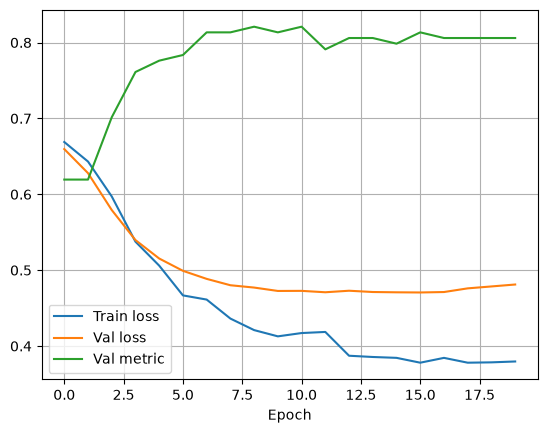

In [38]:
import matplotlib.pyplot as plt

epochs = range(len(history))
train_losses = [h["train_loss"] for h in history]
val_losses = [h["val_loss"] for h in history]
val_metrics = [h["val_metric"] for h in history]

plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses, label="Val loss")
plt.plot(epochs, val_metrics, label="Val metric")

plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [51]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic regression": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(C=1.0, max_iter=2000)
    ),
    "Random forest": make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestClassifier(
            n_estimators=500, min_samples_leaf=2,
            random_state=42, n_jobs=-1
        )
    ),
    "Extra Trees": make_pipeline(
        SimpleImputer(strategy="median"),
        ExtraTreesClassifier(
            n_estimators=500, min_samples_leaf=2,
            random_state=42, n_jobs=-1
        )
    ),
    "RBF SVM": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        SVC(C=1.0, gamma="scale")
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    print(f"{name}: {scores.mean():.3f} +- {scores.std()}")

Logistic regression: 0.833 +- 0.020046482787279545
Random forest: 0.835 +- 0.01413623448906814
Extra Trees: 0.831 +- 0.015443525897847777
RBF SVM: 0.826 +- 0.01802476104523107
XGBoost: 0.837 +- 0.010937883845382006
